In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
df1 = pd.read_csv('../data/data_final_with_aadt.csv')

In [3]:
#Filter data on bridges and AADT of trucks
df_bridges = df1[df1['model_type'] == 'bridge']
df_bridges = df_bridges.sort_values(by = 'avg_truck_AADT', ascending = False)


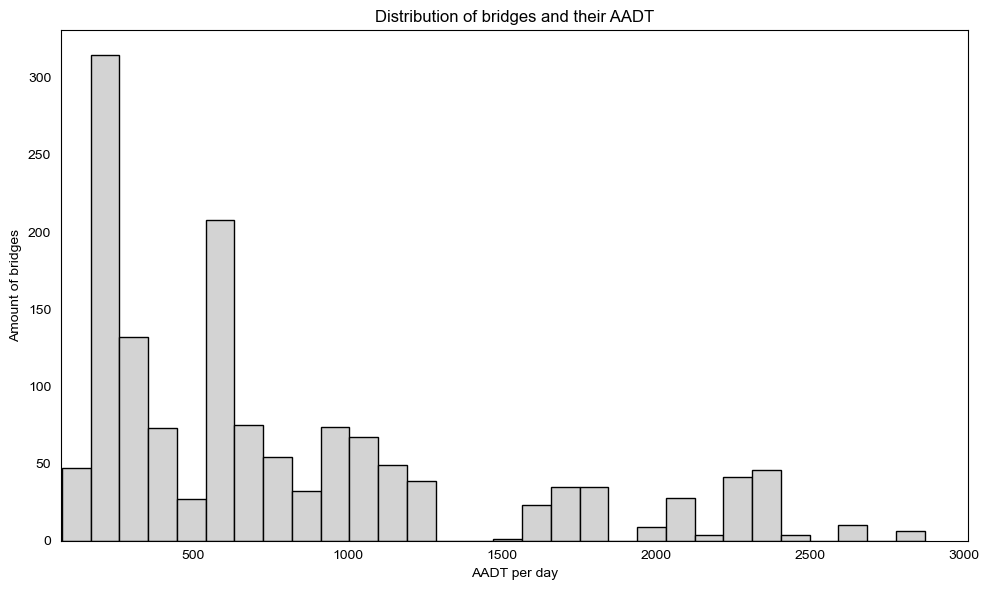

In [4]:
#Visualisation of the distribution of bridges and their AADT
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")

ax.hist(
    df_bridges['avg_truck_AADT'],
    bins=30,
    edgecolor='black',
    color='lightgray'
)

ax.set_title('Distribution of bridges and their AADT', color='black')
ax.set_xlabel('AADT per day', color='black')
ax.set_ylabel('Amount of bridges', color='black')

ax.tick_params(axis='both', colors='black')
for spine in ax.spines.values():
    spine.set_color('black')

ax.grid(axis='y', alpha=0.3)
plt.xlim(70)
plt.tight_layout()
plt.savefig("bridges_aadt_distribution.png", dpi=300, facecolor="white", bbox_inches="tight")
plt.show()

In [5]:
#Bridges with top 5% highest average truck AADT
n_top = math.ceil(len(df_bridges) * 0.05)

#Select bridge with smallest AADT in n_top
cutoff_aadt = df_bridges.iloc[n_top - 1]['avg_truck_AADT']

#Select all bridges with AADT that are higher or equal to the smallest AADT bridge in n_top
top_bridges = df_bridges[df_bridges['avg_truck_AADT'] >= cutoff_aadt]

print("Amount of selected bridges", len(top_bridges))
print(top_bridges.head())

Amount of selected bridges 92
    Unnamed: 0 road      id model_type condition name        lat        lon  \
8            8   N1  100009     bridge         B  NaN  23.696400  90.535099   
10          10   N1  100011     bridge         A  NaN  23.694391  90.537574   
12          12   N1  100013     bridge         A  NaN  23.694302  90.537707   
14          14   N1  100015     bridge         A  NaN  23.692360  90.540918   
16          16   N1  100017     bridge         B  NaN  23.690912  90.545462   

    length  avg_truck_AADT  
8      8.0     2872.333333  
10     6.3     2872.333333  
12     6.3     2872.333333  
14     8.3     2872.333333  
16    10.6     2872.333333  


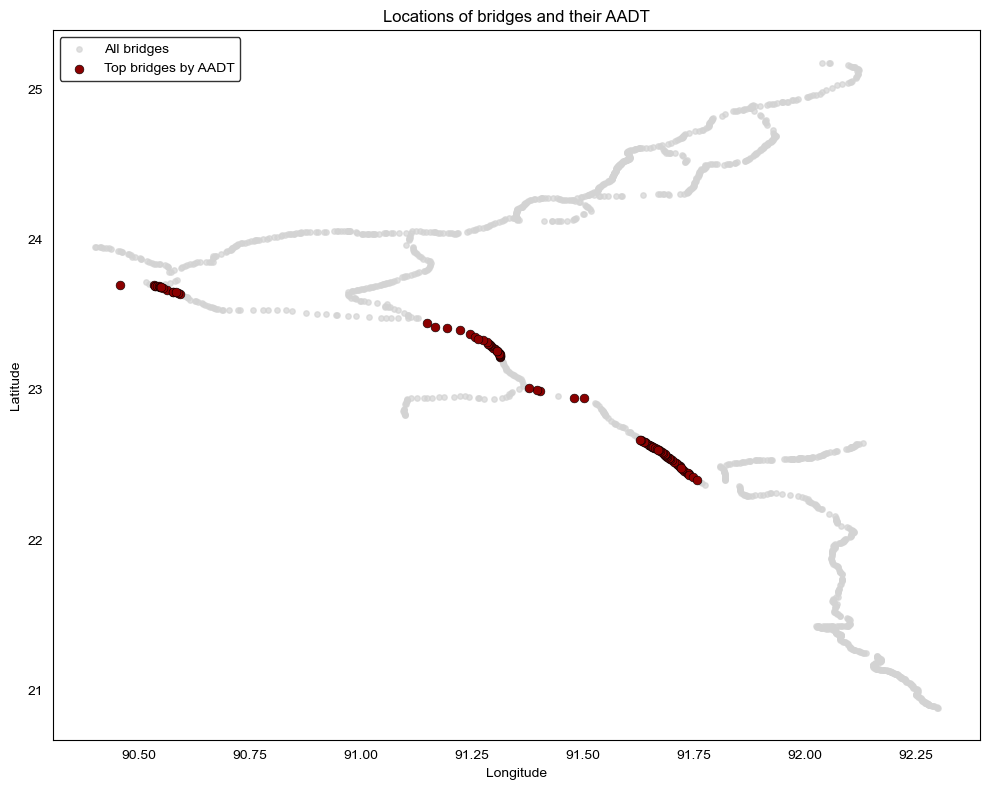

In [6]:
#Visualisation of bridges in the network and the top criticality bridges according to the AADT flow
fig, ax = plt.subplots(figsize=(10, 8), facecolor="white")
ax.set_facecolor("white")

ax.scatter(
    df_bridges["lon"],
    df_bridges["lat"],
    c="lightgray",
    s=15,
    alpha=0.7,
    label="All bridges"
)

ax.scatter(
    top_bridges["lon"],
    top_bridges["lat"],
    c="darkred",
    s=40,
    edgecolors="black",
    linewidths=0.4,
    label="Top bridges by AADT"
)

ax.set_xlabel("Longitude", color="black")
ax.set_ylabel("Latitude", color="black")
ax.set_title("Locations of bridges and their AADT", color="black")

ax.tick_params(axis="both", colors="black")
for spine in ax.spines.values():
    spine.set_color("black")

legend = ax.legend(facecolor="white", edgecolor="black")
for text in legend.get_texts():
    text.set_color("black")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("bridges_plot_traffic_flow.png", dpi=300, facecolor="white", bbox_inches="tight")
plt.show()
